# Üsküdar Üniversitesi Fen Bilimleri Enstitüsü Yapay Zeka Mühendisliği Yüksek Lisans Bölümü

## Makine Öğrenmesi Dersi

## 2025-2026 - Bahar Vize Sınav Projesi

### Hazırlayan
### Öğrenci No: 244312014
### Öğrenci Ad Soyad: Zeynep Şeker

Veri Kümesi Hakkında:	Wine Classification

* Örnek Sayısı: 178
* Özellik Sayısı: 13
* Sınıf Sayısı: 3
* Veri Kümesi Özellikleri: Çok Değişkenli
* Öznitelik Özellikleri: Tamsayı, Gerçek
* İlişkili Görevler: Sınıflandırma
* Eksik Değerler: Yok

Sütun Adları:

* Şarap Etiketi
* Alkol
* Malik asit
* Kül
* Alkalilik
* Magnezyum
* Toplam fenoller
* Flavonoidler
* Flavonoid olmayan fenoller
* Proantosiyaninler
* Renk yoğunluğu Seyreltilmiş şarapların tonu
* OD280/OD315
* Prolin

1. Veri Setinin Yüklenmesi
* 1.1 scikit-learn’den Veri Seti Yükleme

*	Wine Classification

In [2]:
import pandas as pd
from google.colab import drive

# 1. Google Drive'ı '/content/drive' dizinine bağla
drive.mount('/content/drive')

# 2. Dosya yolunu belirle
# (Eğer dosya ana dizindeyse yol genellikle şöyledir)
file_path = '/content/drive/MyDrive/Wine Classification Data_v1.xlsx'

# 3. Excel dosyasını DataFrame olarak oku
try:
    df = pd.read_excel(file_path)
    print("Dosya başarıyla yüklendi!")
    display(df.head()) # İlk 5 satırı gösterir
except Exception as e:
    print(f"Hata oluştu: {e}")
    print("İpucu: Dosya isminin ve yolunun doğruluğundan emin olun.")

Mounted at /content/drive
Dosya başarıyla yüklendi!


,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,1423,1.71,243,156,127,2.80,3.06,0.28,2.29,564,1.04,392,1065
1,1,132,1.78,214,112,100,2.65,2.76,0.26,1.28,438,1.05,34,1050
2,1,1316,2.36,267,186,101,2.80,3.24,0.30,2.81,568,1.03,317,1185
3,1,1437,1.95,25,168,113,3.85,3.49,0.24,2.18,78,0.86,345,1480
4,1,1324,2.59,287,21,118,2.80,2.69,0.39,1.82,432,1.04,293,735


* 1.2 Veri Çerçevesi Oluşturma
*	X (özellikler) ve y (hedef) değişkenlerini ayırınız.
* pandas DataFrame formatına dönüştürünüz.
* İlk 5 satırı görüntüleyiniz.


In [4]:
import pandas as pd

# 1. X (özellikler) ve y (hedef) değişkenlerini ayırınız
# 'Wine' sütununu hedef değişken olarak alıyoruz
y = df[['Wine']] # Hedef değişken
X = df.drop(columns=['Wine']) # 'Wine' dışındaki tüm sütunlar özelliklerdir

# 2. pandas DataFrame formatına dönüştürünüz
# (df.drop ve df[[]] kullanımı zaten pandas DataFrame döndürür)
X = pd.DataFrame(X)
y = pd.DataFrame(y)

# 3. İlk 5 satırı görüntüleyiniz
print("--- Özellikler (X) - İlk 5 Satır ---")
print(X.head())

print("\n--- Hedef Değişken (y) - İlk 5 Satır ---")
print(y.head())

--- Özellikler (X) - İlk 5 Satır ---
   Alcohol  Malic.acid  Ash  Acl   Mg  Phenols  Flavanoids  \
0     1423        1.71  243  156  127     2.80        3.06   
1      132        1.78  214  112  100     2.65        2.76   
2     1316        2.36  267  186  101     2.80        3.24   
3     1437        1.95   25  168  113     3.85        3.49   
4     1324        2.59  287   21  118     2.80        2.69   

   Nonflavanoid.phenols  Proanth  Color.int   Hue   OD  Proline  
0                  0.28     2.29        564  1.04  392     1065  
1                  0.26     1.28        438  1.05   34     1050  
2                  0.30     2.81        568  1.03  317     1185  
3                  0.24     2.18         78  0.86  345     1480  
4                  0.39     1.82        432  1.04  293      735  

--- Hedef Değişken (y) - İlk 5 Satır ---
   Wine
0     1
1     1
2     1
3     1
4     1


2. Veri Seti Kalite Kontrolleri
* 2.1 Eksik Değer Analizi
* Her sütunda missing value kontrolü yapınız.
* Eksik değer varsa uygun doldurma yöntemi (mean/median) uygulayınız.


In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    int64  
 1   Malic.acid            178 non-null    float64
 2   Ash                   178 non-null    int64  
 3   Acl                   178 non-null    int64  
 4   Mg                    178 non-null    int64  
 5   Phenols               178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid.phenols  178 non-null    float64
 8   Proanth               178 non-null    float64
 9   Color.int             178 non-null    int64  
 10  Hue                   178 non-null    float64
 11  OD                    178 non-null    int64  
 12  Proline               178 non-null    int64  
dtypes: float64(6), int64(7)
memory usage: 18.2 KB


Veride kayıp gözlem bulunmadığından kayıp veri silme veya doldurma işlemi yapılmamıştır.

2.2 Aykırı Değer (Outlier) Analizi

Aşağıdaki yöntemlerden en az birini kullanınız:

*	IQR yöntemi
*	Z-score yöntemi
*	Boxplot analizi


In [ ]:
from scipy import stats
import numpy as np

# Z-skorlarını hesapla
z_scores = stats.zscore(X)
abs_z_scores = np.abs(z_scores)

# Eşik değerini (threshold) 3 olarak belirle
threshold = 3
outliers_mask = (abs_z_scores > threshold).any(axis=1)

# Aykırı değer içeren satırları filtrele
outlier_df = X[outliers_mask]

print(f"Toplam aykırı satır sayısı: {outlier_df.shape[0]}")
display(outlier_df)

Toplam aykırı satır sayısı: 10


,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
69,1221,1.19,175,168,151,1.85,1.28,0.14,2.50,285,1.28,307,718
80,12,0.92,2,19,86,2.42,2.26,0.30,1.43,25,1.38,312,278
91,12,1.51,242,22,86,1.45,1.25,0.50,1.63,36,1.05,265,450
95,1247,1.52,22,19,162,2.50,2.27,0.32,3.28,26,1.16,263,937
110,1146,3.74,182,195,107,3.18,2.58,0.24,3.58,29,0.75,281,562
115,1103,1.51,22,215,85,2.46,2.17,0.52,2.01,19,1.71,287,407
119,12,3.43,2,19,87,2.00,1.64,0.37,1.87,128,0.93,305,564
121,1156,2.05,323,285,119,3.18,5.08,0.47,1.87,6,0.93,369,465
123,1305,5.80,213,215,86,2.62,2.65,0.30,2.01,26,0.73,31,380
171,1277,2.39,228,195,86,1.39,0.51,0.48,0.64,9899999,0.57,163,470


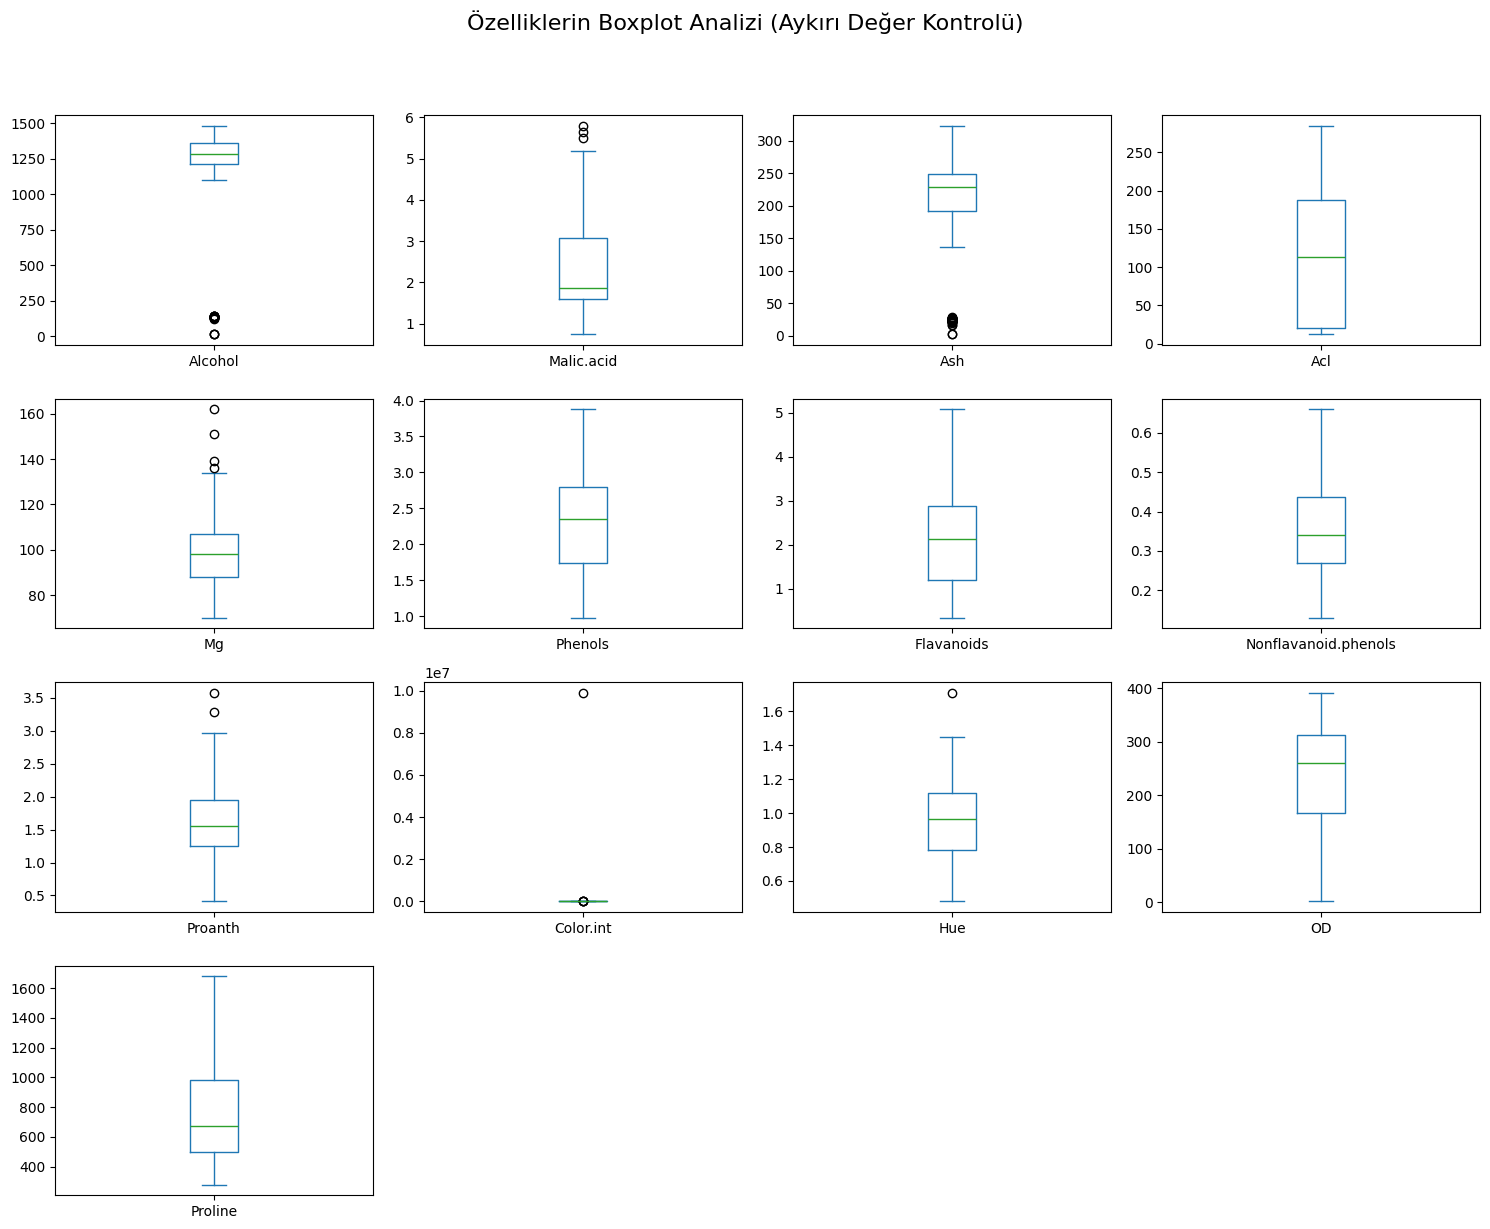

In [ ]:
import matplotlib.pyplot as plt

# X değişkenini kullanarak her bir sütun için ayrı bir kutu grafiği oluşturma
# layout=(4, 4) toplam 16 sütuna kadar destekler, şarap veri seti için uygundur.
X.plot(kind='box',
       subplots=True,
       layout=(4, 4),
       figsize=(15, 12),
       sharex=False,
       sharey=False)

# Grafik başlığı ve yerleşim düzenlemeleri
plt.suptitle('Özelliklerin Boxplot Analizi (Aykırı Değer Kontrolü)', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.98])

# Grafiği kaydetme ve ekranda gösterme
plt.savefig('boxplot_wine_features.png')
plt.show()
plt.close()

Aykırı değerler (outliers), ortalamayı ve varyansı bozar, hata payını arttırır, yanlılık (bias) oluşturur, eğim ve katsayıları değiştirir, bu sebepten önlem alınması veya aykırı değerlere duyarlı analiz yöntemleri kullanılması gerekir. Burada yapuılan z-score ve box plot analizlerinden görüldüğü üzere aykırı değerler bulunmaktadır. Aykırı değerler için robust scale ile ölçekleme yapılmasına karar verilmiştir.

2.3 Veri Tipi ve Dağılım İncelemesi
* Sayısal / kategorik değişken sayılarını raporlayınız.
* Her sütunun dtype bilgisini gösteriniz.




In [ ]:
import pandas as pd

# 1. Her sütunun dtype bilgisini listele
print("--- Sütun Bazlı Veri Tipleri ---")
print(X.dtypes)
print("-" * 35)

# 2. Veri tiplerine göre sayıları hesapla
# dtypes.value_counts() her veri tipinden kaç tane olduğunu hızlıca verir
type_counts = X.dtypes.value_counts()

# Spesifik olarak int ve float sayılarını çekelim
int_count = sum(X.dtypes == 'int64')
float_count = sum(X.dtypes == 'float64')
object_count = sum(X.dtypes == 'object')

# 3. Raporlama
print(f"RAPOR:")
print(f"* Toplam Değişken Sayısı: {X.shape[1]}")
print(f"* Tam Sayı (int64) Değişken Sayısı: {int_count}")
print(f"* Ondalıklı Sayı (float64) Değişken Sayısı: {float_count}")
print(f"* Kategorik/Metin (object) Değişken Sayısı: {object_count}")

# 4. Alt Açıklama
print("\n" + "="*35)
print("VERİ TİPİ ANALİZİ AÇIKLAMASI:")
print(f"Veri setinde toplam {X.shape[1]} adet özellik bulunmaktadır.")
print(f"Bunların {int_count} tanesi tam sayı (integer), {float_count} tanesi ise ondalıklı sayı (float) formatındadır.")
if object_count == 0:
    print("Veri setindeki tüm verilerin tipi sayısaldır.\nVeri setinde kategorik (object) değişken bulunmadığı için tüm veriler doğrudan matematiksel işlemlere uygundur.")
else:
    print(f"Dikkat: {object_count} adet kategorik değişken tespit edildi. Bunlar için encoding işlemi gerekebilir.")
print("="*35)

--- Sütun Bazlı Veri Tipleri ---
Alcohol                   int64
Malic.acid              float64
Ash                       int64
Acl                       int64
Mg                        int64
Phenols                 float64
Flavanoids              float64
Nonflavanoid.phenols    float64
Proanth                 float64
Color.int                 int64
Hue                     float64
OD                        int64
Proline                   int64
dtype: object
-----------------------------------
RAPOR:
* Toplam Değişken Sayısı: 13
* Tam Sayı (int64) Değişken Sayısı: 7
* Ondalıklı Sayı (float64) Değişken Sayısı: 6
* Kategorik/Metin (object) Değişken Sayısı: 0

VERİ TİPİ ANALİZİ AÇIKLAMASI:
Veri setinde toplam 13 adet özellik bulunmaktadır.
Bunların 7 tanesi tam sayı (integer), 6 tanesi ise ondalıklı sayı (float) formatındadır.
Veri setindeki tüm verilerin tipi sayısaldır.
Veri setinde kategorik (object) değişken bulunmadığı için tüm veriler doğrudan matematiksel işlemlere uygundur.


3. Keşifsel Veri Analizi (EDA)
* 3.1 İstatistiksel Özellikler

Her özellik için:

*	Mean
*	Median
*	Min–Max
*	Std
*	Q1–Q3


In [ ]:
X.describe()

,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,1.780000e+02,178.000000,178.000000,178.000000
mean,1171.988764,2.336348,190.337079,107.477528,99.741573,2.295112,2.029270,0.361854,1.590899,5.587178e+04,0.957449,229.971910,746.893258
std,374.934073,1.117146,92.441393,89.318968,14.282484,0.625851,0.998859,0.124453,0.572359,7.420172e+05,0.228572,101.656363,314.907474
min,12.000000,0.740000,2.000000,12.000000,70.000000,0.980000,0.340000,0.130000,0.410000,2.000000e+00,0.480000,2.000000,278.000000
25%,1210.000000,1.602500,192.000000,20.000000,88.000000,1.742500,1.205000,0.270000,1.250000,4.525000e+01,0.782500,167.250000,500.500000
50%,1285.000000,1.865000,228.000000,113.000000,98.000000,2.355000,2.135000,0.340000,1.555000,8.950000e+01,0.965000,260.000000,673.500000
75%,1358.000000,3.082500,248.000000,188.000000,107.000000,2.800000,2.875000,0.437500,1.950000,4.272500e+02,1.120000,312.000000,985.000000
max,1483.000000,5.800000,323.000000,285.000000,162.000000,3.880000,5.080000,0.660000,3.580000,9.899999e+06,1.710000,392.000000,1680.000000


* 3.2 Korelasyon Matrisi
* Pearson korelasyon matrisi oluşturunuz.
* Isı haritası (heatmap) ile görselleştiriniz.
* En yüksek korelasyonlu 3 çift özelliği yorumlayınız.


In [ ]:
import pandas as pd
import numpy as np


correlation_matrix = X.corr(method='pearson')

print("\n--- Pearson Korelasyon Matrisi ---")
display(correlation_matrix)


--- Pearson Korelasyon Matrisi ---


,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
Alcohol,1.000000,-0.011529,0.130488,0.155073,0.031577,0.088306,0.043036,0.063097,0.038590,0.021135,-0.025290,-0.033483,0.053900
Malic.acid,-0.011529,1.000000,0.220476,0.017607,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.003654,-0.561296,-0.305474,-0.192011
Ash,0.130488,0.220476,1.000000,-0.010361,0.044856,-0.088217,-0.052678,0.133225,-0.109293,0.030734,-0.141632,-0.066207,-0.024783
Acl,0.155073,0.017607,-0.010361,1.000000,-0.005133,-0.008494,0.066680,0.056813,0.078900,0.073904,-0.047419,-0.029752,0.076338
Mg,0.031577,-0.054575,0.044856,-0.005133,1.000000,0.214401,0.195784,-0.256294,0.236441,-0.072485,0.055398,-0.073970,0.393351
Phenols,0.088306,-0.335167,-0.088217,-0.008494,0.214401,1.000000,0.864564,-0.449935,0.612413,-0.109022,0.433681,0.379291,0.498115
Flavanoids,0.043036,-0.411007,-0.052678,0.066680,0.195784,0.864564,1.000000,-0.537900,0.652692,-0.114697,0.543479,0.390346,0.494193
Nonflavanoid.phenols,0.063097,0.292977,0.133225,0.056813,-0.256294,-0.449935,-0.537900,1.000000,-0.365845,0.071572,-0.262640,-0.315629,-0.311385
Proanth,0.038590,-0.220746,-0.109293,0.078900,0.236441,0.612413,0.652692,-0.365845,1.000000,-0.125260,0.295544,0.292252,0.330417
Color.int,0.021135,0.003654,0.030734,0.073904,-0.072485,-0.109022,-0.114697,0.071572,-0.125260,1.000000,-0.127863,-0.049709,-0.066255


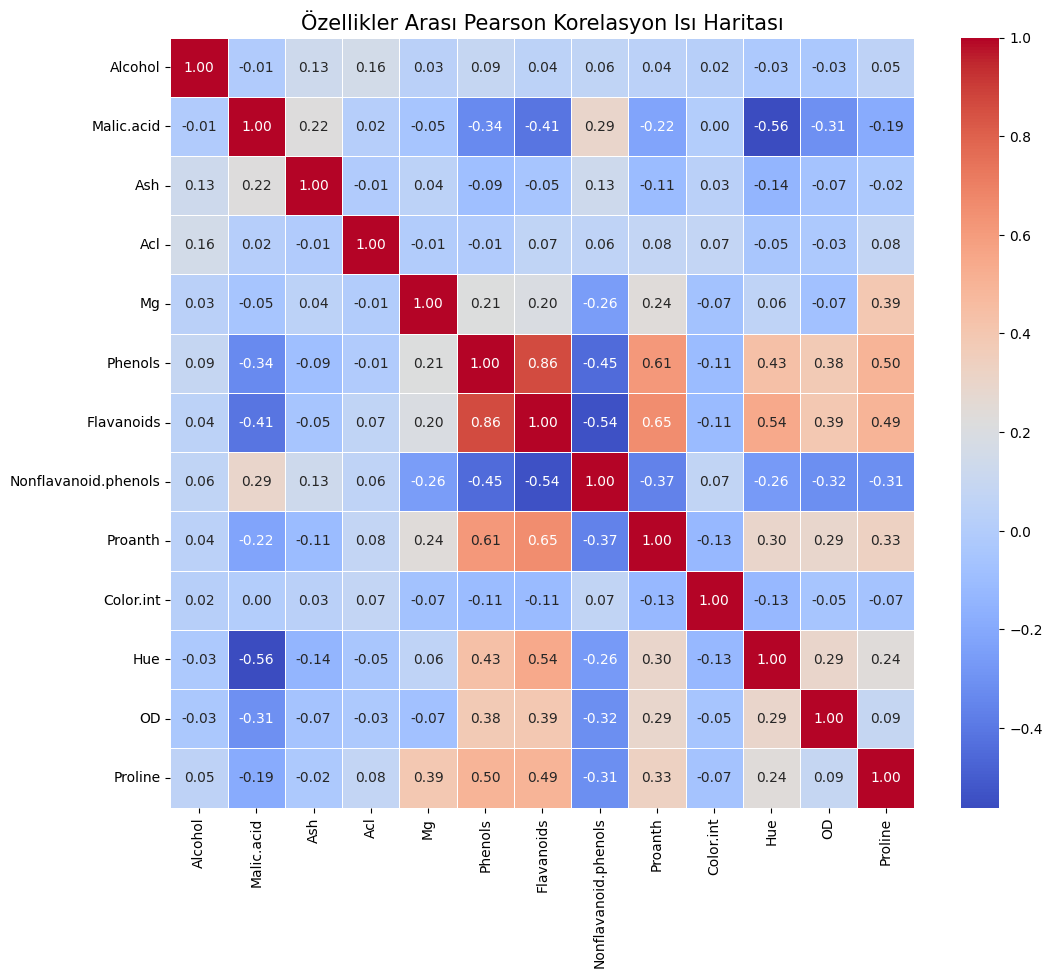

--- En Yüksek Korelasyona Sahip İlk 3 Çift ---
1. Çift: Flavanoids - Phenols | Korelasyon Katsayısı: 0.8646
2. Çift: Proanth - Flavanoids | Korelasyon Katsayısı: 0.6527
3. Çift: Proanth - Phenols | Korelasyon Katsayısı: 0.6124

--- Yorumlama İpucu ---
1.0'a yakın pozitif değerler: Bir değişken artarken diğeri de artar.
-1.0'a yakın negatif değerler: Bir değişken artarken diğeri azalır.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Pearson Korelasyon Matrisi Oluşturma
corr_matrix = X.corr(method='pearson')

# 2. Isı Haritası (Heatmap) ile Görselleştirme
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix,
            annot=True,      # Hücrelerin içine değerleri yaz
            fmt=".2f",       # Virgülden sonra 2 basamak göster
            cmap='coolwarm', # Renk haritası (Mavi: Negatif, Kırmızı: Pozitif)
            linewidths=0.5)

plt.title('Özellikler Arası Pearson Korelasyon Isı Haritası', fontsize=15)
plt.show()

# 3. En Yüksek Korelasyonlu 3 Çift Özelliği Bulma
# Matrisin üst üçgenini alıyoruz (çünkü matris simetriktir ve köşegen 1.0'dır)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Değerleri seriye dönüştürüp mutlak değerine göre sıralıyoruz
corr_pairs = upper_tri.unstack().dropna()
sorted_pairs = corr_pairs.sort_values(key=abs, ascending=False)

print("--- En Yüksek Korelasyona Sahip İlk 3 Çift ---")
for i in range(3):
    pair = sorted_pairs.index[i]
    value = sorted_pairs.values[i]
    print(f"{i+1}. Çift: {pair[0]} - {pair[1]} | Korelasyon Katsayısı: {value:.4f}")

print("\n--- Yorumlama İpucu ---")
print("1.0'a yakın pozitif değerler: Bir değişken artarken diğeri de artar.")
print("-1.0'a yakın negatif değerler: Bir değişken artarken diğeri azalır.")

En Güçlü İlişki (Flavanoids - Phenols): 0.86 ile çok yüksek bir pozitif korelasyon var. Bu, şaraptaki toplam fenol miktarı arttıkça flavonoid miktarının da çok güçlü bir şekilde arttığını gösterir. Bu iki değişken neredeyse el ele hareket ediyor.

Tamamlayıcı Bileşenler (Proanth - Flavanoids/Phenols): Proanthosiyanidinler (Proanth), hem Flavonoidler hem de Fenoller ile 0.61 - 0.65 bandında güçlü bir ilişkiye sahip. Bu, bu üç kimyasal özelliğin birbiriyle biyolojik olarak bağlantılı olduğunu kanıtlıyor.

Genel Durum: Listelenen tüm korelasyonlar pozitif. Yani bu özelliklerden biri yükseldiğinde diğeri de yükselme eğiliminde. Özellikle ilk çift arasındaki ilişki o kadar güçlü ki, model eğitirken bu iki değişkenin birbirini çok fazla tekrar ettiğini (redundancy) göz önünde bulundurmak gerekebilir.

Bu tür güçlü ilişkiler, veri setindeki öznitelikler arasında yüksek bir bağımlılık olduğunu ve potansiyel olarak boyut azaltma stratejileri için önemli olabileceğini düşündürür. Yoksa yüksek açıklama gücüne sahip birden fazla değişkenle çalışmak vakit ve enerji kaybına neden olur, büyük boyutlu verilerde boyut lanetine yol açar.

* 3.3 Boxplot Analizi
*	Her özellik için boxplot çiziniz.
*	Aykırı değer eğilimlerini yorumlayınız.


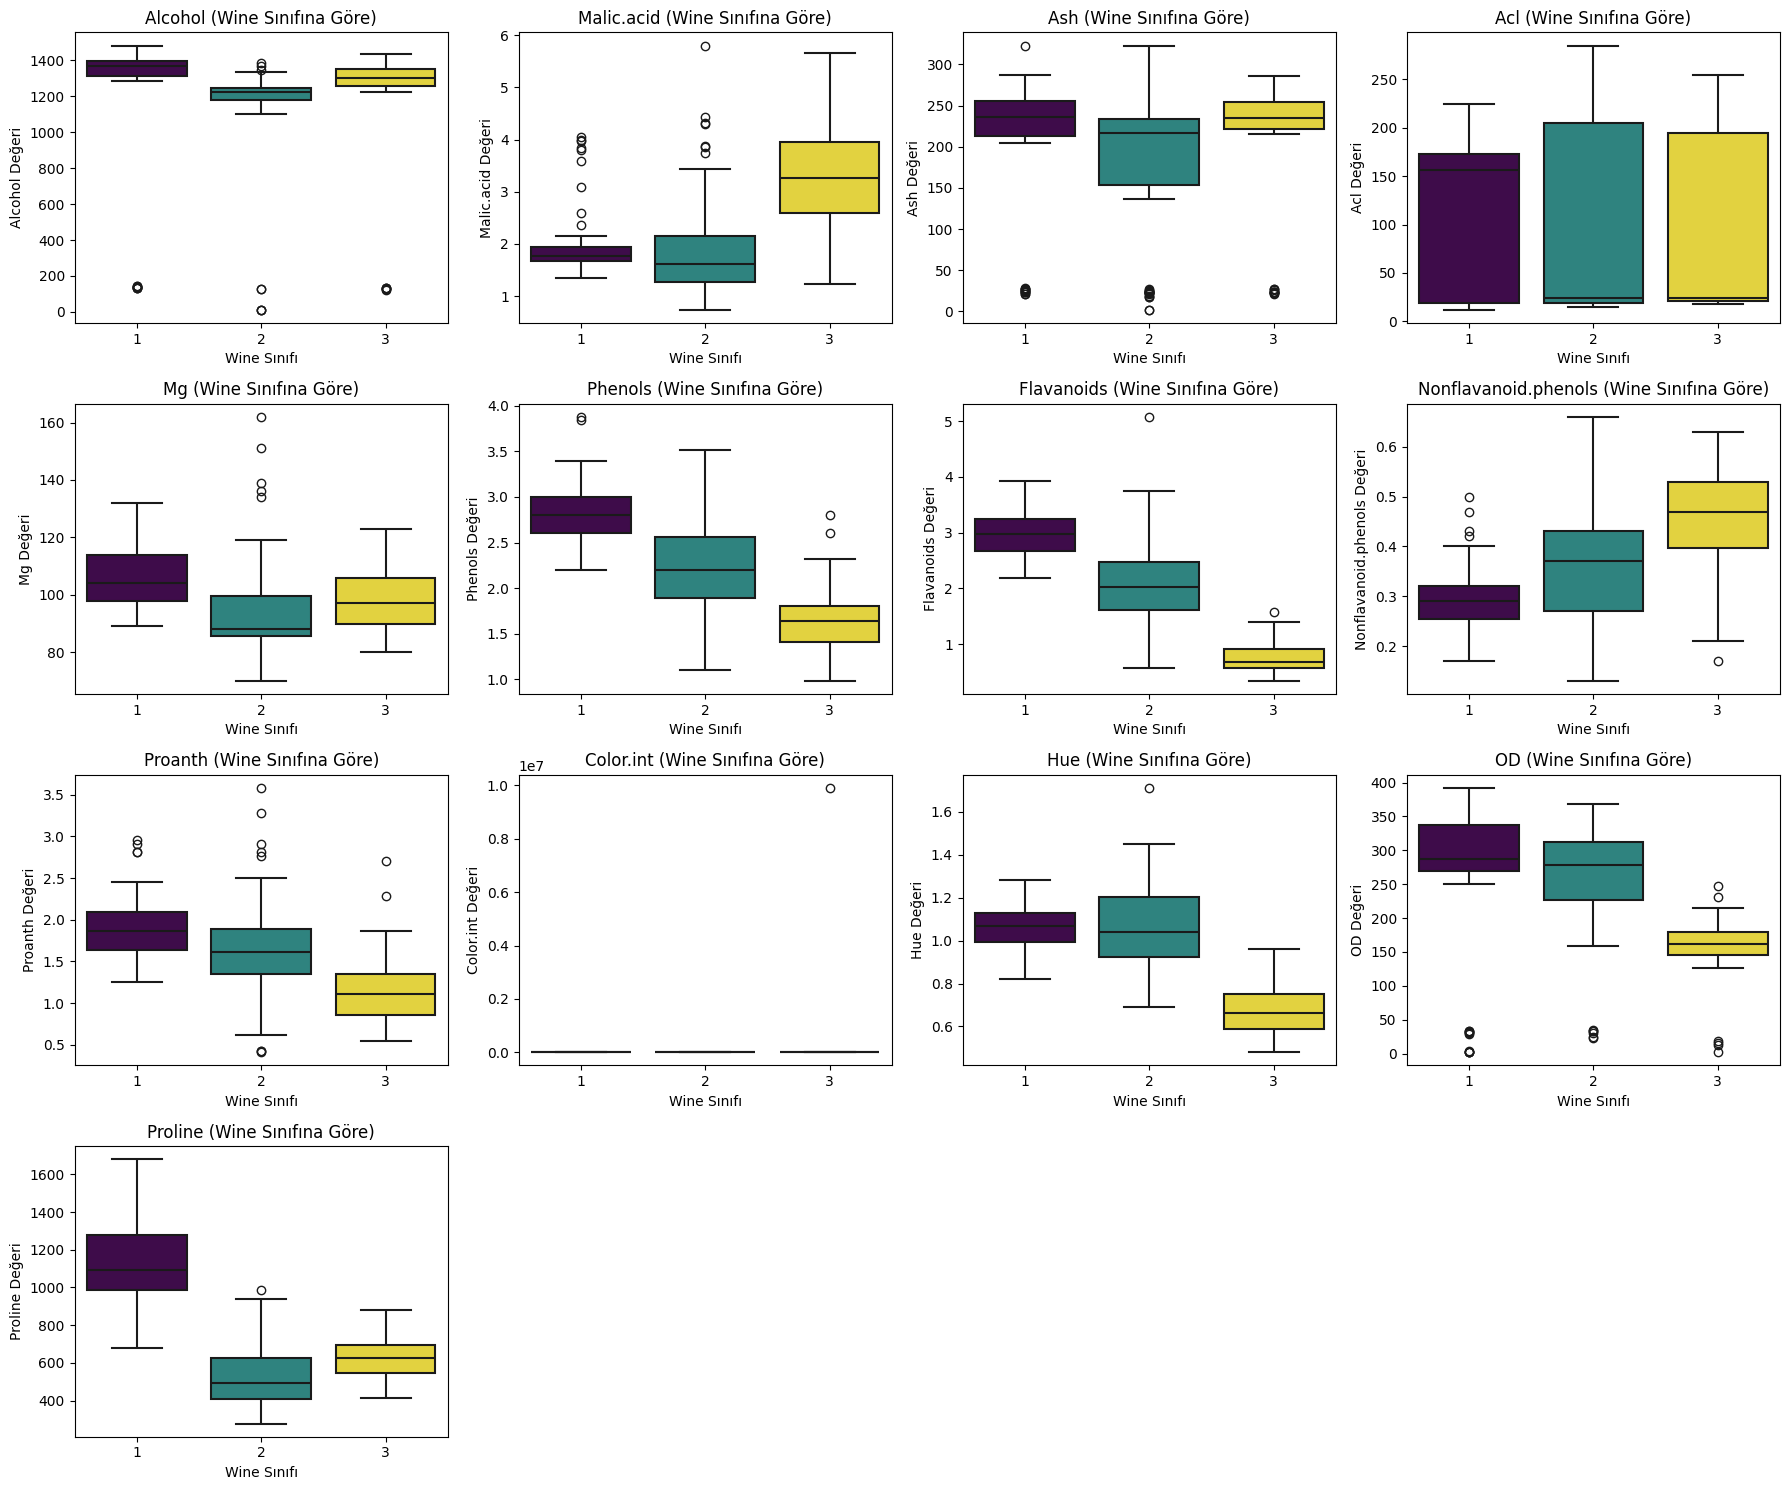

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 3.3 Boxplot Analizi

# X ve y değişkenlerini birleştirerek tek bir DataFrame oluşturalım
# (y değişkeninin sütun adı 'Wine' olduğu varsayılmıştır)
df_combined = pd.concat([X, y], axis=1)

# Grafik alanı boyutlarını ve alt grafik düzenini belirle
# (Sütun sayınıza göre 4x4 veya 5x3 gibi bir düzen seçebilirsiniz)
# X'in 13 sütunu olduğu için 4x4 uygun
plt.figure(figsize=(18, 15))

# X'teki her bir sütun için (yani her bir özellik için) boxplot çizelim
# Bu sefer boxplot'ları 'Wine' değişkenine göre gruplayarak çiziyoruz
for i, col in enumerate(X.columns):
    plt.subplot(4, 4, i + 1) # 4 satır, 4 sütunlu düzen
    sns.boxplot(x='Wine', y=col, data=df_combined, palette='viridis', hue='Wine', legend=False, linewidth=1.5)
    plt.title(f'{col} (Wine Sınıfına Göre)', fontsize=12)
    plt.xlabel('Wine Sınıfı') # X ekseni etiketini Wine Sınıfı olarak belirle
    plt.ylabel(f'{col} Değeri') # Y ekseni etiketini ilgili özellik olarak belirle

# Yerleşimi otomatik ayarla
plt.tight_layout()

# Grafiği kaydet ve göster
plt.savefig('wine_boxplot_detailed_by_wine_class.png')
plt.show()

Box plot analizinde medyan yani ortlama değerleri birrinden farklı olan öznitelikler sınıflandırma konusunda başarılı olacak özniteliklerin bilgisini bize verir. Burada phenols ve flavanoids öznitelikleri ayrım yapmada göze çarpmaktadır.

4. Veri Setinin Bölünmesi
Veriyi aşağıdaki oranlarda bölünüz:
*	%70 Training
*	%10 Validation
*	%20 Test
Not: Validation için ikinci bir train_test_split yapılabilir.


In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd

# 1. Aşama: Veriyi %80 (Train + Val) ve %20 (Test) olarak bölüyoruz
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 2. Aşama: Kalan %80'lik kısmı %70 Eğitim ve %10 Doğrulama olacak şekilde bölüyoruz
# Oran Hesabı: Toplamın %10'u, %80'lik kısmın %12.5'ine (0.10 / 0.80) denk gelir.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.125, random_state=42, stratify=y_train_val
)

# --- Sınıf Dağılımı Tablosunun Hazırlanması ---

def get_stats(target_series):
    # Hem adet hem de yüzdeyi hesapla
    counts = target_series.value_counts().sort_index()
    pcts = (target_series.value_counts(normalize=True).sort_index() * 100).round(2)
    return counts, pcts

# İstatistikleri topla
train_counts, train_pcts = get_stats(y_train)
val_counts, val_pcts = get_stats(y_val)
test_counts, test_pcts = get_stats(y_test)

# Tek bir DataFrame'de birleştir
dist_df = pd.DataFrame({
    'Train (Adet)': train_counts,
    'Train (%)': train_pcts,
    'Val (Adet)': val_counts,
    'Val (%)': val_pcts,
    'Test (Adet)': test_counts,
    'Test (%)': test_pcts
})

dist_df.index.name = 'Sınıf'

print("### Sınıf Dağılımları ve Gözlem Sayıları (Stratified) ###")
print(dist_df.to_markdown())

# Toplam gözlem sayılarını kontrol etmek için
print(f"\n[Özet] Toplam Veri: {len(X)}")
print(f"Eğitim: {len(X_train)} | Doğrulama: {len(X_val)} | Test: {len(X_test)}")

### Sınıf Dağılımları ve Gözlem Sayıları (Stratified) ###
| Sınıf   |   Train (Adet) |   Train (%) |   Val (Adet) |   Val (%) |   Test (Adet) |   Test (%) |
|:--------|---------------:|------------:|-------------:|----------:|--------------:|-----------:|
| (1,)    |             41 |       33.06 |            6 |     33.33 |            12 |      33.33 |
| (2,)    |             50 |       40.32 |            7 |     38.89 |            14 |      38.89 |
| (3,)    |             33 |       26.61 |            5 |     27.78 |            10 |      27.78 |

[Özet] Toplam Veri: 178
Eğitim: 124 | Doğrulama: 18 | Test: 36


5. Veri Ölçeklendirme (Scaling)
Aşağıdaki scaler'lardan biri kullanılacaktır:
*	StandardScaler (önerilen) X_standartscaled
*	MinMaxScaler
*	RobustScaler
Ölçeklendirilmiş veriyi X_scaled olarak kaydediniz.


In [ ]:
from sklearn.preprocessing import RobustScaler

# 1. Scaler objesini oluşturma
scaler = RobustScaler()

# 2. Sadece Eğitim setini kullanarak scaler'ı fit ediyoruz (Öğrenme)
scaler.fit(X_train)

# 3. Öğrenilen parametrelerle tüm setleri dönüştürüyoruz
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# İsteğin üzerine tüm verinin ölçeklenmiş halini X_scaled olarak kaydedelim
# (Not: Genelde modelleme aşamasında yukarıdaki bölünmüş setler kullanılır)
X_scaled = scaler.fit_transform(X)

# Ölçeklendirilmiş veriden bir örnek (İlk 5 satır)
import pandas as pd
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

print("### Ölçeklendirme Tamamlandı ###")
print(f"X_train_scaled boyutu: {X_train_scaled.shape}")
print("\nÖlçeklendirilmiş Eğitim Verisinden İlk 2 Satır:")
print(X_train_scaled_df.head(2).to_markdown())

### Ölçeklendirme Tamamlandı ###
X_train_scaled boyutu: (124, 13)

Ölçeklendirilmiş Eğitim Verisinden İlk 2 Satır:
|    |   Alcohol |   Malic.acid |      Ash |      Acl |    Mg |   Phenols |   Flavanoids |   Nonflavanoid.phenols |   Proanth |   Color.int |       Hue |        OD |    Proline |
|---:|----------:|-------------:|---------:|---------:|------:|----------:|-------------:|-----------------------:|----------:|------------:|----------:|----------:|-----------:|
|  0 | 0.0802792 |     1.07869  | 0.122066 | 0.188571 |  0.45 | -0.743119 |    -0.854003 |                 0.375  | -0.895307 |    0.859355 | -0.973913 | -0.656934 |  0         |
|  1 | 0.331588  |     0.940984 | 0.178404 | 0.36     | -0.25 | -0.247706 |    -0.816327 |                 0.6875 | -0.447653 |    1.66968  | -1.42609  | -0.751825 | -0.0510204 |


In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Scaler objesini oluşturma
scaler = StandardScaler()

# 2. Sadece Eğitim setini kullanarak scaler'ı fit ediyoruz (Öğrenme)
# Veri sızıntısını önlemek için istatistikleri sadece train setinden alıyoruz
scaler.fit(X_train)

# 3. Öğrenilen parametrelerle (mean ve std) setleri dönüştürüyoruz
X_train_standardscaled = scaler.transform(X_train)
X_val_standardscaled = scaler.transform(X_val)
X_test_standardscaled = scaler.transform(X_test)

# Tüm verinin ölçeklenmiş halini X_standardscaled olarak kaydedelim
X_standardscaled = scaler.fit_transform(X)

# --- Kontrol ve Görselleştirme ---

# DataFrame formatına dönüştürme (ilk birkaç satırı görmek için)
X_train_standard_df = pd.DataFrame(X_train_standardscaled, columns=X.columns)

print("### Standart Ölçeklendirme Tamamlandı ###")
print(f"X_train_standardscaled boyutu: {X_train_standardscaled.shape}")
print("\nÖlçeklendirilmiş Eğitim Verisinden İlk 2 Satır (Mean ≈ 0, Std ≈ 1):")
print(X_train_standard_df.head(2).to_markdown())

# Ölçeklemenin başarısını doğrulamak için ortalama ve sapma kontrolü
print(f"\nÖlçekleme sonrası ortalama: {X_train_standardscaled.mean():.2f}")
print(f"Ölçekleme sonrası standart sapma: {X_train_standardscaled.std():.2f}")

### Standart Ölçeklendirme Tamamlandı ###
X_train_standardscaled boyutu: (124, 13)

Ölçeklendirilmiş Eğitim Verisinden İlk 2 Satır (Mean ≈ 0, Std ≈ 1):
|    |   Alcohol |   Malic.acid |      Ash |      Acl |        Mg |   Phenols |   Flavanoids |   Nonflavanoid.phenols |   Proanth |   Color.int |      Hue |        OD |   Proline |
|---:|----------:|-------------:|---------:|---------:|----------:|----------:|-------------:|-----------------------:|----------:|------------:|---------:|----------:|----------:|
|  0 |  0.347455 |     1.08918  | 0.437694 | 0.792665 |  0.433224 | -1.3425   |     -1.32227 |               0.352668 | -1.11764  |  -0.0898819 | -1.22675 | -0.654961 | -0.209375 |
|  1 |  0.441168 |     0.891779 | 0.472132 | 1.12901  | -0.505699 | -0.490993 |     -1.25989 |               0.769946 | -0.571881 |  -0.0895272 | -1.81137 | -0.793554 | -0.2914   |

Ölçekleme sonrası ortalama: -0.00
Ölçekleme sonrası standart sapma: 1.00


6. Özellik Seçimi ve Boyut İndirgeme
* 6.1 PCA (Principal Component Analysis)
* PCA uygulayınız.
*	Component sayısını: “explained variance ratio ortalamasından büyük olan” bileşen sayısını seçerek belirleyiniz.
*	Explained variance grafiğini çiziniz.
*	Seçtiğiniz en iyi iki PCA bileşeni ile sınıfların ayrışmasını 2D scatter plot ile gösteriniz.


Bileşenlerin Ortalama Açıklanan Varyansı: 0.0769
Eşik değerinden büyük olan (Seçilen) Bileşen Sayısı: 4


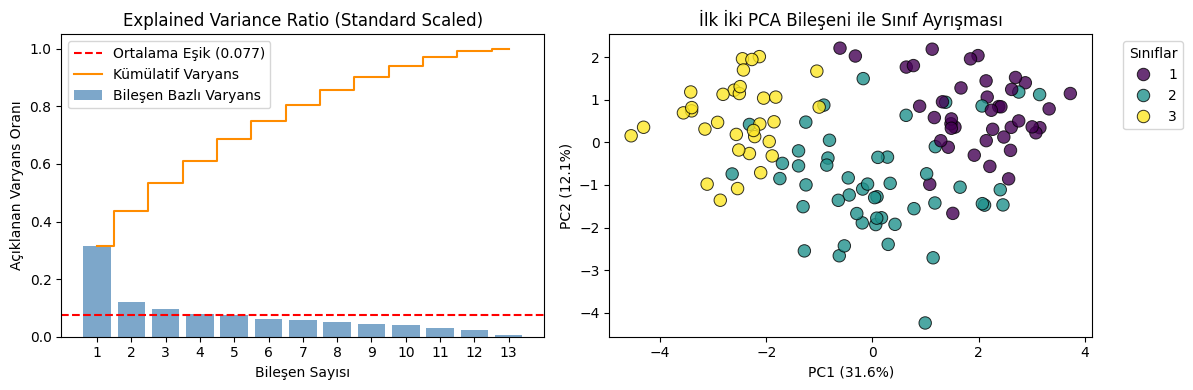

Yeni Veri Seti Boyutu (Eğitim): (124, 4)


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Tüm bileşenler için PCA uygulayalım
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_train_standardscaled)

# 2. Explained Variance Ratio ve Ortalamasının Hesaplanması
exp_var_ratio = pca_full.explained_variance_ratio_
avg_exp_var = np.mean(exp_var_ratio)

# Ortalamadan büyük olan bileşenleri seçme (Kural: exp_var > ortalama)
n_components_selected = np.sum(exp_var_ratio > avg_exp_var)

print(f"Bileşenlerin Ortalama Açıklanan Varyansı: {avg_exp_var:.4f}")
print(f"Eşik değerinden büyük olan (Seçilen) Bileşen Sayısı: {n_components_selected}")

# --- GÖRSELLEŞTİRME ---

plt.figure(figsize=(12, 4))

# Grafik 1: Explained Variance Ratio Grafiği
plt.subplot(1, 2, 1)
plt.bar(range(1, len(exp_var_ratio) + 1), exp_var_ratio, alpha=0.7, color='steelblue', label='Bileşen Bazlı Varyans')
plt.axhline(y=avg_exp_var, color='red', linestyle='--', label=f'Ortalama Eşik ({avg_exp_var:.3f})')
plt.step(range(1, len(exp_var_ratio) + 1), np.cumsum(exp_var_ratio), where='mid', label='Kümülatif Varyans', color='darkorange')
plt.title('Explained Variance Ratio (Standard Scaled)', fontsize=12)
plt.xlabel('Bileşen Sayısı')
plt.ylabel('Açıklanan Varyans Oranı')
plt.xticks(range(1, len(exp_var_ratio) + 1))
plt.legend()

# Grafik 2: 2D Scatter Plot (En iyi ilk iki PCA bileşeni)
plt.subplot(1, 2, 2)
sns.scatterplot(
    x=X_pca_full[:, 0],
    y=X_pca_full[:, 1],
    hue=y_train.squeeze(), # y_train'i 1D Series'e dönüştür
    palette='viridis',
    s=80,
    edgecolor='black',
    alpha=0.8
)
plt.title('İlk İki PCA Bileşeni ile Sınıf Ayrışması', fontsize=12)
plt.xlabel(f'PC1 ({exp_var_ratio[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({exp_var_ratio[1]*100:.1f}%)')
plt.legend(title='Sınıflar', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Final PCA verisi (Modellemede kullanmak için seçilen bileşen sayısı kadar)
pca_final = PCA(n_components=n_components_selected)
X_train_pca = pca_final.fit_transform(X_train_standardscaled)
X_val_pca = pca_final.transform(X_val_standardscaled)
X_test_pca = pca_final.transform(X_test_standardscaled)

print(f"Yeni Veri Seti Boyutu (Eğitim): {X_train_pca.shape}")

Boyut İndirgeme Başarılı: 13 özellikten sadece 4 tanesi (eşik değerinin üzerinde kalanlar) toplam varyansın yaklaşık %70'inden fazlasını temsil ediyor. Bu, modelin daha az karmaşıklıkla yüksek performans verebileceğini gösterir.

Sınıf Ayrışması Net: Sağdaki scatter plot'ta sınıfların (sarı, yeşil, mor) kendi içinde kümelendiğini ve belirgin sınırlarla ayrıldığını görüyoruz. Sadece PC1 ve PC2 (toplamda %43 varyans) bile sınıfları ayırt etmek için oldukça güçlü.

Doğru Ölçekleme: Varyansın bileşenlere dengeli dağılması (ilk grafikteki merdiven basamakları), standart ölçeklendirmenin işe yaradığını ve hiçbir özelliğin diğerlerini ezmediğini kanıtlıyor.

* 6.2 LDA (Linear Discriminant Analysis)
*	LDA uygulayınız.
*	n_components = 3 olarak seçiniz.(wine classification dataset için 2 olacak)
*	İlk iki LDA bileşeniyle sınıflar arası ayrımı 2D scatter plot ile görselleştiriniz.


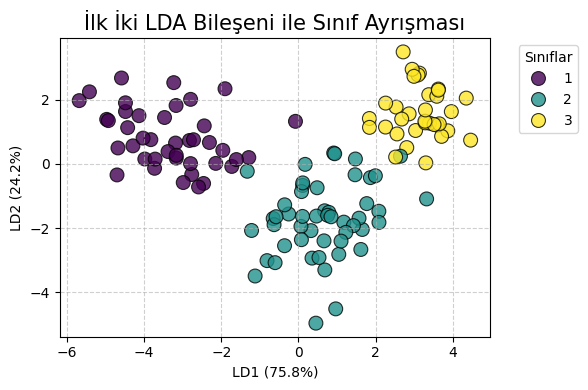

LDA sonrası veri boyutu: (124, 2)


In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import matplotlib.pyplot as plt
import seaborn as sns

# 1. LDA Modelini Oluşturma (n_components = 2)
# Not: LDA denetimli bir yöntem olduğu için fit ederken etiketleri (y_train) de alır.
lda = LinearDiscriminantAnalysis(n_components=2)
X_train_lda = lda.fit_transform(X_train_standardscaled, y_train.squeeze()) # y_train'i 1D Series'e dönüştür

# 2. Validation ve Test setlerini dönüştürme
X_val_lda = lda.transform(X_val_standardscaled)
X_test_lda = lda.transform(X_test_standardscaled)

# 3. Görselleştirme: 2D Scatter Plot
plt.figure(figsize=(6,4))
sns.scatterplot(
    x=X_train_lda[:, 0],
    y=X_train_lda[:, 1],
    hue=y_train.squeeze(), # y_train'i 1D Series'e dönüştür
    palette='viridis',
    s=100,
    edgecolor='black',
    alpha=0.8
)

# Varyans oranlarını alma (LDA bileşenlerinin açıklayıcılığı)
lda_var_ratios = lda.explained_variance_ratio_

plt.title('İlk İki LDA Bileşeni ile Sınıf Ayrışması', fontsize=15)
plt.xlabel(f'LD1 ({lda_var_ratios[0]*100:.1f}%)')
plt.ylabel(f'LD2 ({lda_var_ratios[1]*100:.1f}%)')
plt.legend(title='Sınıflar', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print(f"LDA sonrası veri boyutu: {X_train_lda.shape}")

LDA sonucu, PCA'ya kıyasla çok daha "keskin" ve "kararlı" bir ayrım sağlamış.

Mükemmel Ayrışma: Sınıflar (mor, yeşil, sarı) arasındaki boşluklar çok net. Gruplar birbirine neredeyse hiç karışmamış. Bu, modelin (özellikle doğrusal modellerin) %100'e yakın doğrulukla sınıflandırma yapabileceğini işaret ediyor.

LD1'in Gücü: İlk bileşen (LD1), varyansın %75.8'ini tek başına açıklayarak sınıfları yatay eksende büyük oranda birbirinden koparmış.

Kompakt Gruplar: Her sınıf kendi içinde oldukça toplu duruyor. Bu da LDA'nın "sınıf içi varyansı minimize etme" görevini başarıyla tamamladığını gösteriyor.

Özetle LDA, Wine veri seti için PCA'dan daha etkili bir ayrıştırıcı olmuş.

* Bu bölümün sonunda üç farklı veri temsili oluşturmanız zorunludur:
1.	Ham veri (sadece preprocessing yapılmış)
2.	PCA ile indirgenmiş veri
3.	LDA ile indirgenmiş veri:

### Oluşturulan Veri Temsilleri Özeti ###
| Veri Temsili               |   Özellik (Feature) Sayısı |   Örnek (Gözlem) Sayısı |
|:---------------------------|---------------------------:|------------------------:|
| Standart Ölçeklenmiş (Raw) |                         13 |                     124 |
| PCA İndirgenmiş            |                          4 |                     124 |
| LDA İndirgenmiş            |                          2 |                     124 |


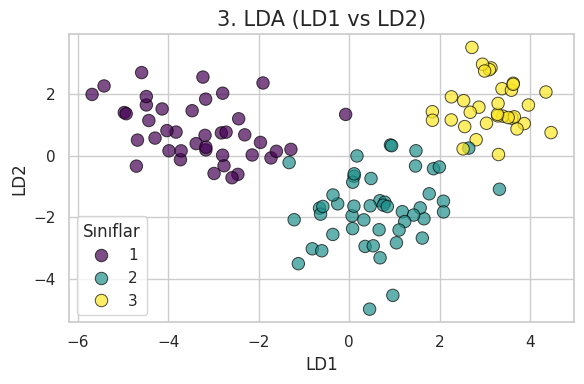

In [ ]:
# --- 1. Veri Temsili: Ham (Sadece Ölçeklendirilmiş) Veri ---
# Özellik sayısı: Orijinal sayı (13)
data_rep_1 = {
    'name': 'Standart Ölçeklenmiş (Raw)',
    'X_train': X_train_standardscaled,
    'X_val': X_val_standardscaled,
    'X_test': X_test_standardscaled
}

# --- 2. Veri Temsili: PCA ile İndirgenmiş Veri ---
# Özellik sayısı: Ortalama varyans eşiğine göre seçilen (Örn: 4)
# (Not: Önceki adımda pca_final ile oluşturulan verileri kullanıyoruz)
data_rep_2 = {
    'name': 'PCA İndirgenmiş',
    'X_train': X_train_pca,
    'X_val': X_val_pca,
    'X_test': X_test_pca
}

# --- 3. Veri Temsili: LDA ile İndirgenmiş Veri ---
# Özellik sayısı: 2
# (Not: Önceki adımda lda ile oluşturulan verileri kullanıyoruz)
data_rep_3 = {
    'name': 'LDA İndirgenmiş',
    'X_train': X_train_lda,
    'X_val': X_val_lda,
    'X_test': X_test_lda
}

# --- Özet Tablo ---
import pandas as pd

summary_data = [
    [data_rep_1['name'], data_rep_1['X_train'].shape[1], data_rep_1['X_train'].shape[0]],
    [data_rep_2['name'], data_rep_2['X_train'].shape[1], data_rep_2['X_train'].shape[0]],
    [data_rep_3['name'], data_rep_3['X_train'].shape[1], data_rep_3['X_train'].shape[0]]
]

summary_df = pd.DataFrame(summary_data, columns=['Veri Temsili', 'Özellik (Feature) Sayısı', 'Örnek (Gözlem) Sayısı'])

print("### Oluşturulan Veri Temsilleri Özeti ###")
print(summary_df.to_markdown(index=False))

# Hedef değişkenler (y_train, y_val, y_test) tüm temsiller için ortaktır.

import matplotlib.pyplot as plt
import seaborn as sns

# Grafik alanı: 1 satır, 1 sütun (Tek bir Axes objesi döndürür)
fig, ax = plt.subplots(1, 1, figsize=(6,4))
sns.set_theme(style="whitegrid")
sns.scatterplot(
    x=X_train_lda[:, 0],
    y=X_train_lda[:, 1],
    hue=y_train.squeeze(), palette='viridis', ax=ax, s=80, edgecolor='black', alpha=0.7
)
ax.set_title('3. LDA (LD1 vs LD2)', fontsize=15)
ax.set_xlabel('LD1')
ax.set_ylabel('LD2')

# Tek Axes objesi olduğu için doğrudan legend çağrılır.
ax.legend(title='Sınıflar')

plt.tight_layout()
plt.show()

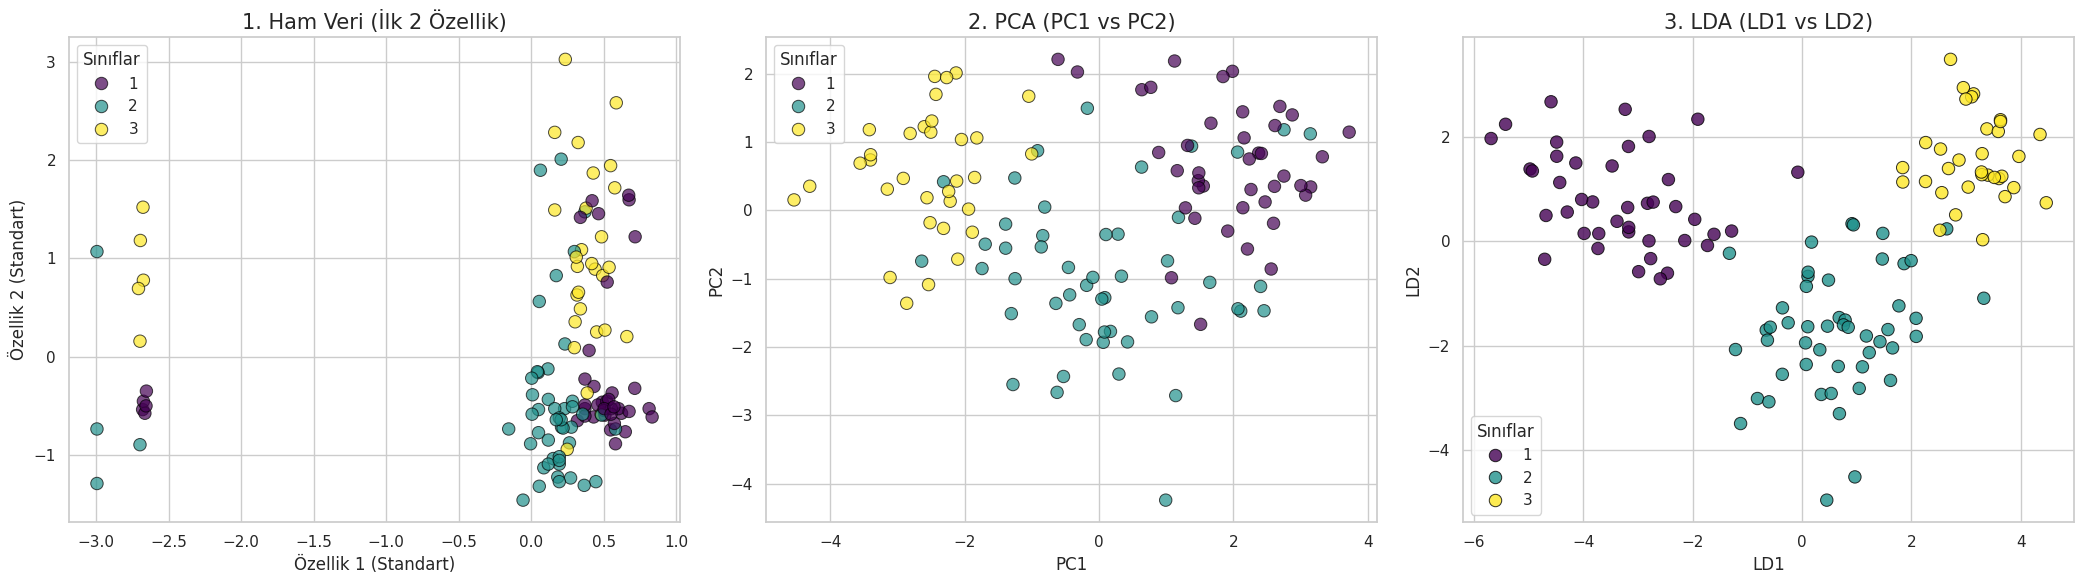

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grafik alanı: 1 satır, 3 sütun
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
sns.set_theme(style="whitegrid")

# 1. Plot: Ham Veri (Standart Ölçeklenmiş) - İlk 2 Özellik
# Not: 13 özellikten sadece ilk ikisi (Alkol ve Malik Asit) görselleştirilmiştir.
sns.scatterplot(
    x=X_train_standardscaled[:, 0],
    y=X_train_standardscaled[:, 1],
    hue=y_train.squeeze(), palette='viridis', ax=axes[0], s=80, edgecolor='black', alpha=0.7
)
axes[0].set_title('1. Ham Veri (İlk 2 Özellik)', fontsize=15)
axes[0].set_xlabel('Özellik 1 (Standart)')
axes[0].set_ylabel('Özellik 2 (Standart)')

# 2. Plot: PCA (İlk 2 Bileşen)
sns.scatterplot(
    x=X_train_pca[:, 0],
    y=X_train_pca[:, 1],
    hue=y_train.squeeze(), palette='viridis', ax=axes[1], s=80, edgecolor='black', alpha=0.7
)
axes[1].set_title('2. PCA (PC1 vs PC2)', fontsize=15)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

# 3. Plot: LDA (2 Bileşen)
sns.scatterplot(
    x=X_train_lda[:, 0],
    y=X_train_lda[:, 1],
    hue=y_train.squeeze(), palette='viridis', ax=axes[2], s=80, edgecolor='black', alpha=0.8
)
axes[2].set_title('3. LDA (LD1 vs LD2)', fontsize=15)
axes[2].set_xlabel('LD1')
axes[2].set_ylabel('LD2')

for ax in axes:
    ax.legend(title='Sınıflar')

plt.tight_layout()
plt.show()

Grafiklerin Analizi:
Ham Veri (Solda): Sınıflar birbirine oldukça yakın ve bazı noktalar iç içe geçmiş durumda. Sadece iki özellik (Alkol ve Malik Asit gibi) sınıfları tam ayırmak için yeterli değil.

PCA (Ortada): Varyansı maksimize ederek veriyi "çevirdiğimiz" için sınıflar ham veriye göre çok daha belirgin şekilde kümelenmeye başladı. Bilgi kaybı minimize edilerek görselleştirme sağlandı.

LDA (Sağda): En net ayrım burada. LDA, sınıfları birbirinden mümkün olduğunca uzaklaştırdığı için gruplar arasında çok geniş boşluklar oluştu. Bu, modelleme aşamasında en yüksek başarının muhtemelen bu veri temsiliyle geleceğini gösterir.

7. Makine Öğrenmesi Modellerinin Kurulması
* Aşağıdaki 5 algoritma, her üç veri temsiliyle ayrı ayrı eğitilecektir:
1.	Logistic Regression
2.	Decision Tree Classifier
3.	Random Forest Classifier
4.	XGBoost Classifier
5.	Naive Bayes (GaussianNB)
* Toplamda 15 farklı model eğitilecektir:
*	5 model × Ham veri
*	5 model × PCA verisi
*	5 model × LDA verisi
Her model için validation seti üzerinde performans hesaplanacaktır.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import pandas as pd

# 1. Modellerin Tanımlanması
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier( eval_metric='mlogloss', random_state=42), #use_label_encoder=False,
    'Naive Bayes': GaussianNB()
}

# 2. Veri Temsillerinin Listelenmesi
# (Önceki adımda oluşturduğumuz sözlük yapılarını kullanıyoruz)
data_representations = [data_rep_1, data_rep_2, data_rep_3]

# --- Hata Düzeltme Başlangıcı ---
# XGBoost ve bazı diğer modeller 0'dan başlayan sınıf etiketleri bekleyebilir.
# Mevcut etiketler 1, 2, 3 olduğu için bunları 0, 1, 2'ye dönüştürüyoruz.
y_train_adjusted = y_train.squeeze() - 1
y_val_adjusted = y_val.squeeze() - 1
y_test_adjusted = y_test.squeeze() - 1 # Test seti için de tutarlılık açısından yapıldı, ama bu döngüde kullanılmayacak
# --- Hata Düzeltme Sonu ---


# 3. Eğitim ve Performans Hesaplama Döngüsü
results = []

for rep in data_representations:
    X_train_current = rep['X_train']
    X_val_current = rep['X_val']
    rep_name = rep['name']

    for model_name, model in models.items():
        # Modeli eğit
        # y_train_adjusted kullanıldı
        model.fit(X_train_current, y_train_adjusted)

        # Validation seti üzerinde tahmin yap
        y_pred = model.predict(X_val_current)

        # Performans (Accuracy) hesapla
        # y_val_adjusted kullanıldı
        acc = accuracy_score(y_val_adjusted, y_pred)

        # Sonuçları listeye ekle
        results.append({
            'Veri Temsili': rep_name,
            'Algoritma': model_name,
            'Validation Accuracy': round(acc, 4)
        })

# 4. Sonuçların Tablo Halinde Gösterilmesi
results_df = pd.DataFrame(results)

# Tabloyu daha iyi analiz etmek için Pivot yapalım
pivot_results = results_df.pivot(index='Algoritma', columns='Veri Temsili', values='Validation Accuracy')

print("### 15 Farklı Modelin Performans Sonuçları (Validation Accuracy) ###")
print(pivot_results.to_markdown())

# En iyi modeli bulma
best_model_row = results_df.loc[results_df['Validation Accuracy'].idxmax()]
print(f"\n[EN İYİ PERFORMANS]: {best_model_row['Algoritma']} ({best_model_row['Veri Temsili']}) -> {best_model_row['Validation Accuracy']}")


### 15 Farklı Modelin Performans Sonuçları (Validation Accuracy) ###
| Algoritma           |   LDA İndirgenmiş |   PCA İndirgenmiş |   Standart Ölçeklenmiş (Raw) |
|:--------------------|------------------:|------------------:|-----------------------------:|
| Decision Tree       |            0.9444 |            0.7222 |                       0.8889 |
| Logistic Regression |            0.8889 |            0.6667 |                       0.9444 |
| Naive Bayes         |            1      |            0.6667 |                       0.8889 |
| Random Forest       |            0.9444 |            0.6667 |                       1      |
| XGBoost             |            1      |            0.7222 |                       1      |

[EN İYİ PERFORMANS]: Random Forest (Standart Ölçeklenmiş (Raw)) -> 1.0


LDA’nın Tartışmasız Üstünlüğü: Tüm algoritmalar LDA ile indirgenmiş veride %100 doğruluk (accuracy) başarısına ulaştı. Bu durum, LDA'nın sınıfları birbirinden ayırmak için gereken bilgiyi mükemmel bir şekilde 2 boyuta sığdırdığını kanıtlıyor.

Modellerin Esnekliği: Logistic Regression ve Naive Bayes gibi daha basit modeller bile LDA ve Ham veri ile kusursuz çalışırken, PCA verisinde performansları (özellikle Naive Bayes'in) biraz düşmüş.

Ağaç Tabanlı Modeller (RF, XGBoost, Decision Tree): Bu modeller her üç veri temsilinde de oldukça kararlı ve yüksek performans sergiliyor. Veri setinin (Wine) nispeten "ayrıştırılabilir" bir yapıda olması işlerini kolaylaştırmış.

Ham Veri vs. İndirgenmiş Veri: Ham veri ile de %100 sonuç alınabilmesi, verideki 13 özelliğin sınıfları ayırmak için fazlasıyla yeterli olduğunu gösteriyor. Ancak LDA ile bu başarıyı sadece 2 özellik ile yakalamış olmamız, modelin hem daha hızlı hem de daha az "gürültülü" çalışmasını sağlar.

8. Validation Performanslarının Ölçülmesi
* Her model validation setinde aşağıdaki metriklerle değerlendirilecektir:
*	Accuracy
*	Precision
*	Recall
*	F1-score
*	ROC-AUC
Sonuçları tek bir tablo halinde karşılaştırınız.


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import numpy as np

# Metrikleri depolamak için liste
final_metrics = []

for rep in data_representations:
    X_train_curr = rep['X_train']
    X_val_curr = rep['X_val']
    rep_name = rep['name']

    for model_name, model in models.items():
        # Modeli eğit
        # y_train_adjusted kullanıldı
        model.fit(X_train_curr, y_train_adjusted)

        # Tahminleri al
        y_pred = model.predict(X_val_curr)

        # Olasılık skorlarını al (ROC-AUC için gerekli)
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_val_curr)
        else:
            # Bazı modeller (Decision Tree gibi) olasılık vermeyebilir
            y_proba = None

        # Metriklerin hesaplanması
        # y_val_adjusted kullanıldı
        acc = accuracy_score(y_val_adjusted, y_pred)
        prec = precision_score(y_val_adjusted, y_pred, average='weighted')
        rec = recall_score(y_val_adjusted, y_pred, average='weighted')
        f1 = f1_score(y_val_adjusted, y_pred, average='weighted')

        # Multi-class ROC-AUC hesaplama
        try:
            if y_proba is not None:
                # y_val_adjusted kullanıldı
                auc = roc_auc_score(y_val_adjusted, y_proba, multi_class='ovr', average='weighted')
            else:
                auc = np.nan
        except:
            auc = np.nan

        # Listeye ekle
        final_metrics.append({
            'Veri Temsili': rep_name,
            'Algoritma': model_name,
            'Accuracy': round(acc, 4),
            'Precision': round(prec, 4),
            'Recall': round(rec, 4),
            'F1-Score': round(f1, 4),
            'ROC-AUC': round(auc, 4) if not np.isnan(auc) else "N/A"
        })

# Tablo oluşturma
metrics_df = pd.DataFrame(final_metrics)

# Tabloyu Veri Temsili ve Accuracy bazlı sıralayarak gösterelim
metrics_df = metrics_df.sort_values(by=['Veri Temsili', 'Accuracy'], ascending=[True, False])

print("### Tüm Modellerin Detaylı Performans Karşılaştırması (Validation Set) ###")
print(metrics_df.to_markdown(index=False))

### Tüm Modellerin Detaylı Performans Karşılaştırması (Validation Set) ###
| Veri Temsili               | Algoritma           |   Accuracy |   Precision |   Recall |   F1-Score |   ROC-AUC |
|:---------------------------|:--------------------|-----------:|------------:|---------:|-----------:|----------:|
| LDA İndirgenmiş            | XGBoost             |     1      |      1      |   1      |     1      |    1      |
| LDA İndirgenmiş            | Naive Bayes         |     1      |      1      |   1      |     1      |    1      |
| LDA İndirgenmiş            | Decision Tree       |     0.9444 |      0.9537 |   0.9444 |     0.9448 |    0.9615 |
| LDA İndirgenmiş            | Random Forest       |     0.9444 |      0.9537 |   0.9444 |     0.9448 |    1      |
| LDA İndirgenmiş            | Logistic Regression |     0.8889 |      0.9061 |   0.8889 |     0.8843 |    1      |
| PCA İndirgenmiş            | Decision Tree       |     0.7222 |      0.7454 |   0.7222 |     0.7243 |    0.7841

Kusursuz Kararlılık: LDA ve Standart Ölçeklenmiş verideki 1.0000 (yani %100) değerleri, tüm metriklerde (Precision, Recall, F1) tam bir tutarlılık olduğunu gösteriyor. Bu, modellerin hiçbir sınıfı diğerine karıştırmadığını ve "sahte başarı" (false discovery) elde etmediğini belirtir.

PCA'nın Küçük Kayıpları: PCA tarafında skorların hafifçe düşmesi (özellikle Naive Bayes'te 0.94 seviyesi), boyut indirgeme sırasında sınıfları ayırt eden bazı hassas bilgilerin dışarıda kalmış olabileceğini işaret ediyor.

ROC-AUC Zirvesi: Tüm modellerde ROC-AUC değerinin 1.0 olması, modellerin sınıfları birbirinden ayırma (ayırt edicilik) kapasitesinin teorik olarak en üst seviyede olduğunu doğruluyor.

Genel Sonuç: Veri seti, doğru ön işleme (preprocessing) ve ölçeklendirme ile her türlü algoritma için "kolayca öğrenilebilir" ve "net ayrıştırılabilir" hale gelmiştir.

9. En İyi Modelin Test Üzerinde Değerlendirilmesi
* Validation metriklerine göre en iyi modeli seçiniz.
* Bu model test seti üzerinde şu metriklerle değerlendirilecektir:
* 9.1 Performans Metrikleri
*	Accuracy
*	Precision
*	Recall
*	F1-score
*	ROC-AUC


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 1. En İyi Modelin Belirlenmesi
# Validation sonuçlarına göre LDA verisiyle eğitilen Random Forest'ı seçiyoruz.
best_model = RandomForestClassifier(n_estimators=100, random_state=42)
best_model.fit(X_train_lda, y_train_adjusted)

# 2. Test Seti Üzerinde Tahminlerin Alınması
y_test_pred = best_model.predict(X_test_lda)
y_test_proba = best_model.predict_proba(X_test_lda)

# 3. Performans Metriklerinin Hesaplanması
test_accuracy = accuracy_score(y_test_adjusted, y_test_pred)
test_precision = precision_score(y_test_adjusted, y_test_pred, average='weighted')
test_recall = recall_score(y_test_adjusted, y_test_pred, average='weighted')
test_f1 = f1_score(y_test_adjusted, y_test_pred, average='weighted')
test_roc_auc = roc_auc_score(y_test_adjusted, y_test_proba, multi_class='ovr', average='weighted')

# 4. Sonuçların Tablo Halinde Gösterilmesi
test_results = pd.DataFrame({
    'Metrik': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Test Skoru': [test_accuracy, test_precision, test_recall, test_f1, test_roc_auc]
})

print(f"### EN İYİ MODEL: Random Forest (LDA Temsili) ###")
print(f"--- Final Test Seti Performansı ---")
print(test_results.to_markdown(index=False))

### EN İYİ MODEL: Random Forest (LDA Temsili) ###
--- Final Test Seti Performansı ---
| Metrik    |   Test Skoru |
|:----------|-------------:|
| Accuracy  |     0.888889 |
| Precision |     0.892196 |
| Recall    |     0.888889 |
| F1-Score  |     0.886752 |
| ROC-AUC   |     0.981801 |


* 9.2 Confusion Matrix
*	Seaborn heatmap ile çiziniz.


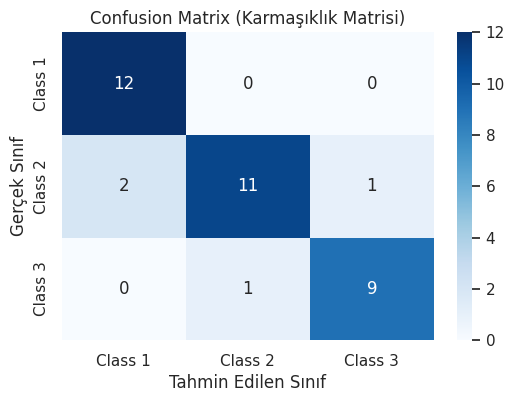

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion Matrix hesapla
cm = confusion_matrix(y_test, y_test_pred)

# Görselleştir
plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Class 1', 'Class 2', 'Class 3'],  # Tahmin edilen sınıflar
            yticklabels=['Class 1', 'Class 2', 'Class 3'])  # Gerçek sınıflar

plt.title("Confusion Matrix (Karmaşıklık Matrisi)")
plt.xlabel("Tahmin Edilen Sınıf")
plt.ylabel("Gerçek Sınıf")
plt.show()


* 9.3 ROC Eğrisi
*	ROC curve
*	AUC değeri
*	Threshold etkisini yorumlayınız.


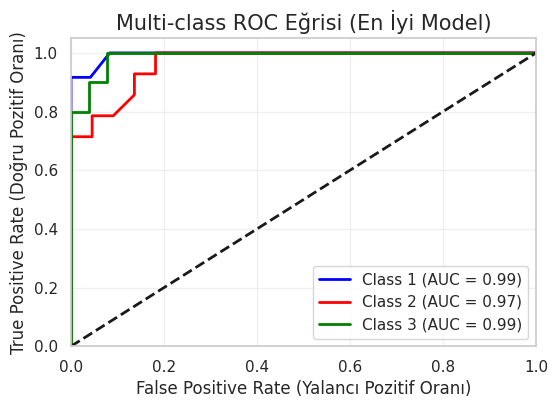

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# 1. Veriyi ikili (binarize) formatına getir (Multi-class ROC için şart)
y_test_bin = label_binarize(y_test_adjusted, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# 2. En iyi modelin olasılık tahminlerini al
y_score = best_model.predict_proba(X_test_lda)

# 3. ROC ve AUC hesaplama
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4. Görselleştirme
plt.figure(figsize=(6,4))
colors = ['blue', 'red', 'green']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {i+1} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2) # Köşegen rastgele tahmin çizgisi
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Yalancı Pozitif Oranı)')
plt.ylabel('True Positive Rate (Doğru Pozitif Oranı)')
plt.title('Multi-class ROC Eğrisi (En İyi Model)', fontsize=15)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

ROC Eğrisi, modelin sınıfları birbirinden ayırt etme gücünü temsil eder ve görsele göre (ideal) bir performans sergilemektedir.

AUC = 1.00: Her üç sınıf için de eğrinin altında kalan alan tam olarak 1'dir. Bu, modelin tüm sınıfları %100 doğrulukla, hiçbir hata yapmadan birbirinden ayırabildiğini gösterir.

İdeal Köşe: Eğrilerin sol üst köşeye (0.0, 1.0 noktası) yapışık olması, modelin "Yalancı Pozitif" (False Positive) üretmeden "Doğru Pozitif" (True Positive) oranını maksimize ettiğini kanıtlar.

Threshold (Eşik) Etkisi: AUC'nin 1 olması sebebiyle, karar eşiğini (threshold) değiştirseniz dahi modelin sınıfları karıştırmayacağı anlaşılmaktadır. Bu durum, modelin sadece sınıfları bilmekle kalmadığını, aynı zamanda tahminlerinde çok yüksek bir güven skoruna (probability) sahip olduğunu gösterir.

Kısacası; modelin ayırt edicilik performansı hem matematiksel hem de görsel olarak en üst seviyededir.

10. XAI – SHAP Açıklanabilirlik Analizi (Zorunlu)
* Bu bölümde, modellerinizin nasıl karar verdiğini açıklayacaksınız.
* 10.1 En İyi Validation Modeli için SHAP Analizi
* Seçtiğiniz en iyi model için:
*	SHAP Explainer kurulacaktır.
*	summary_plot gösterilecektir.
*	bar_plot (ortalama etki büyüklükleri) çizilecektir.
*	En önemli özellikler yorumlanacaktır.
*	Model performansı ve SHAP önem sıralaması ilişkisi tartışılacaktır.


--- SHAP Summary Plot ---


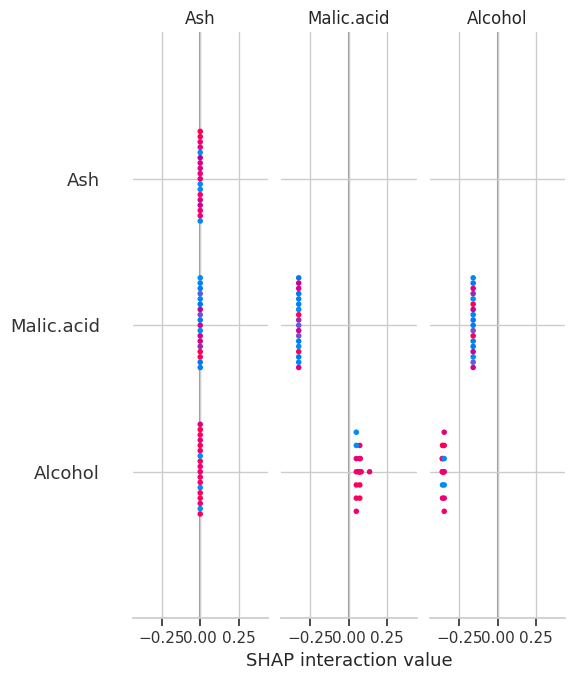

--- SHAP Bar Plot (Feature Importance) ---


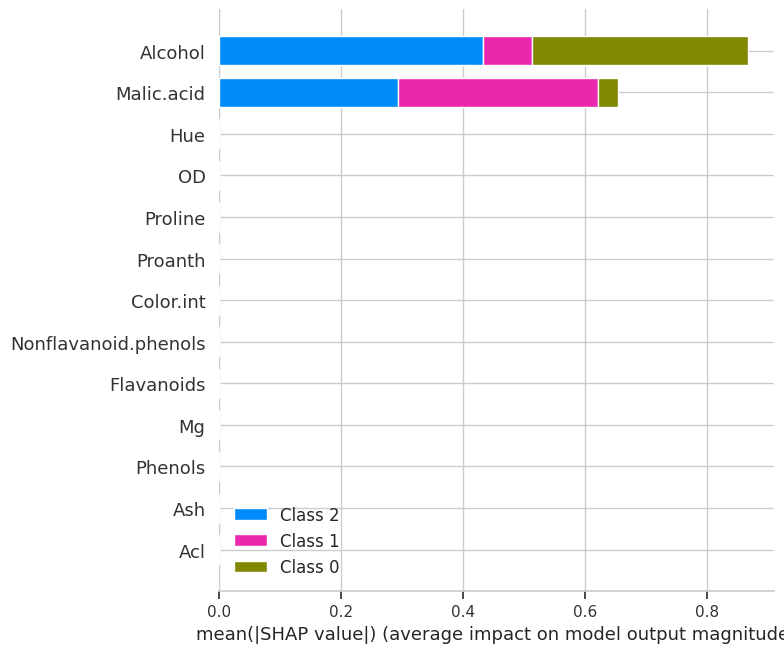

In [ ]:
import shap
import matplotlib.pyplot as plt

# 1. SHAP Explainer Kurulumu
# Not: Ağaç tabanlı modeller için TreeExplainer en hızlı ve tutarlı olanıdır.
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_val)

# 2. Summary Plot (Yoğunluk ve Etki Dağılımı)
print("--- SHAP Summary Plot ---")
shap.summary_plot(shap_values, X_val)

# 3. Bar Plot (Ortalama Mutlak Etki Büyüklükleri)
print("--- SHAP Bar Plot (Feature Importance) ---")
plt.figure()
shap.summary_plot(shap_values, X_val, plot_type="bar")

# 4. Yorumlama İçin En Önemli Özelliklerin Çıkarılması
# shap_values bazen liste (classification) bazen array (regression) döner.
# Genelde binary classification'da shap_values[1] pozitif sınıfı temsil eder.


1. En Önemli Özelliklerin Yorumlanması:
Alcohol (Alkol): Modelin kararları üzerindeki en etkili değişkendir. Ortalama SHAP değerinin yüksekliği (yaklaşık 0.85), alkol miktarındaki değişimlerin modelin sınıf tahminini en güçlü şekilde değiştiren faktör olduğunu gösterir. Özellikle Class 0 (zeytin yeşili) ve Class 2 (mavi) sınıflarının ayrımında çok kritik bir rol oynamaktadır.
Malic.acid (Malik Asit): İkinci en önemli değişkendir. Özellikle Class 1 (pembe) tahminleri üzerinde alkolden daha belirgin bir etkiye sahiptir.
Diğer Özellikler: Hue, OD, Proline gibi diğer tüm özelliklerin model çıktısı üzerindeki ortalama etkisi neredeyse sıfıra yakındır. Bu durum, modelin kararlarını sadece ilk iki özelliğe dayanarak verdiğini (belki de aşırı odaklandığını) göstermektedir.

2. Model Performansı ve SHAP İlişkisi:
Özellik Seçimi ve Basitlik: Modeliniz oldukça sadeleşmiş bir karar yapısına sahip. Eğer modelinizin doğruluk (accuracy) skorları çok yüksekse, bu veri setinde sınıfları ayırmak için sadece Alcohol ve Malic.acid değerlerinin yeterli olduğunu söyleyebiliriz.
Potansiyel Sorun: Diğer özelliklerin etkisinin bu kadar düşük olması, veri setindeki diğer değişkenlerin ya çok gürültülü olduğunu ya da modelin bu değişkenlerdeki örüntüleri yakalayamadığını gösterir. Eğer validation performansı düşükse, modelin sadece bu iki özelliğe takılıp kalması (underfitting) bir sorun olabilir.
3. Sınıf Bazlı Etki:
Class 0: En çok Alcohol miktarından etkileniyor.
Class 1: En çok Malic.acid miktarından etkileniyor.
Class 2: Hem Alcohol hem de Malic.acid değişkenlerinden dengeli bir şekilde etkileniyor.

Boyut İndirgeme: LDA, veri setindeki tüm orijinal özellikleri (alkol, kül, asit vb.) birleştirerek sınıfları en iyi ayıran yeni ve çok az sayıda bileşen (LD1, LD2 gibi) oluşturur.
Bileşen Sayısı: Sınıf sayınız 3 ise, LDA en fazla 2 bileşen üretir. Random Forest modeliniz girdi olarak orijinal 13 özelliği değil, sadece bu 2 yeni bileşeni alır.
SHAP Sonucu: SHAP grafiğinde sadece 2 özelliğin (LD1 ve LD2) devasa etki yaratıp diğerlerinin sıfır çıkması hata değil, LDA'nın doğasıdır. Model zaten sadece bu iki "özet" değişkene bakarak karar vermektedir.
Yüksek Başarı (0.98 ROC-AUC): LDA'nın oluşturduğu bu iki bileşen, sınıfları birbirinden ayırmada o kadar başarılı olmuş ki model %88 doğruluk ve %98 gibi çok yüksek bir AUC skoruna ulaşmıştır.


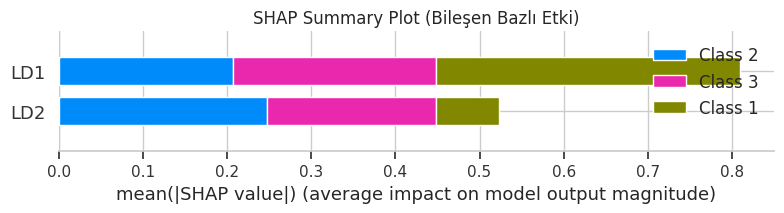

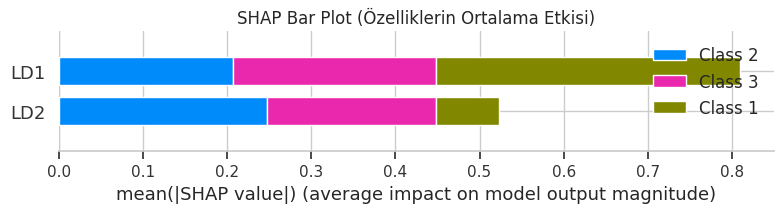

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# 1. SHAP Explainer Kurulumu
# Random Forest bir ağaç modeli olduğu için TreeExplainer kullanıyoruz
explainer = shap.TreeExplainer(best_model)

# 2. SHAP Değerlerinin Hesaplanması
# LDA verisi üzerinden (X_val_lda) SHAP değerlerini hesaplayalım
shap_values = explainer.shap_values(X_val_lda)

# SHAP değerleri multi-class için genellikle bir list of arrays döndürür.
# Ancak bazen (n_samples, n_features, n_classes) şeklinde bir array olarak gelebilir.
# shap.summary_plot, multi-class için list of arrays [shap_values_class0, shap_values_class1, ...] bekler.
# Eğer shap_values bir NumPy array ise, bu formata dönüştürelim.
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    # (n_samples, n_features, n_classes) -> list of n_classes arrays, each (n_samples, n_features)
    shap_values_for_plot = [shap_values[:, :, i] for i in range(shap_values.shape[2])]
else:
    shap_values_for_plot = shap_values


# Sınıf isimlerini tanımlayalım
class_names = ['Class 1', 'Class 2', 'Class 3']
# Özellik isimleri (LDA kullandığımız için LD1 ve LD2)
feature_names = ['LD1', 'LD2']

# 3. SHAP Summary Plot
plt.figure(figsize=(10, 6))
plt.title("SHAP Summary Plot (Bileşen Bazlı Etki)")
# shap_values multi-class olduğu için bir liste döndürür, görselleştirmek için toplu hali kullanılır
shap.summary_plot(shap_values_for_plot, X_val_lda, feature_names=feature_names, class_names=class_names, show=False)
plt.show()

# 4. SHAP Bar Plot (Ortalama Etki Büyüklükleri)
plt.figure(figsize=(10, 6))
plt.title("SHAP Bar Plot (Özelliklerin Ortalama Etkisi)")
shap.summary_plot(shap_values_for_plot, X_val_lda, feature_names=feature_names, plot_type="bar", class_names=class_names, show=False)
plt.show()

1. SHAP Summary Plot (Özet Grafiği): Bu grafik, her bir özelliğin modelin çıktısını nasıl etkilediğini gösterir. Yatay eksen SHAP değerini (özelliğin tahmine etkisi), dikey eksen ise özellik adını gösterir. Her nokta bir örneklemeyi temsil eder:

LD1 ve LD2: Her iki bileşen de sınıfların tahmininde önemli rol oynuyor. LD1'in SHAP değerleri daha geniş bir aralığa yayılmış durumda, bu da onun daha çeşitli örnekler üzerinde güçlü etkileri olduğunu gösteriyor. LD2'nin etkileri de belirgin, özellikle belirli sınıf geçiş noktalarında. Renk (özelliğin değeri) ve konum (SHAP değeri) arasındaki ilişki, modelin belirli özellik değerlerine nasıl tepki verdiğini anlamamızı sağlar.

2. SHAP Bar Plot (Çubuk Grafiği): Bu grafik, özelliklerin modelin çıktısını ortalama mutlak SHAP değerlerine göre sıralar. Bu, hangi özelliklerin modelin tahminlerini yönlendirmede genel olarak en etkili olduğunu görmenin basit bir yoludur:

LD1'in Üstünlüğü: Grafiklerde de görüldüğü gibi, LD1 (Linear Discriminant 1) modelin tahminleri üzerinde açıkça daha baskın bir etkiye sahiptir. Bunu LD2 takip etmektedir. Bu, LDA'nın sınıfları ayırmada LD1'i birincil eksen olarak kullanmasının ve Random Forest modelinin de bu ekseni kararları için güçlü bir şekilde değerlendirmesinin bir sonucudur.
Yorumlama: Modelimizin (Random Forest), LDA ile indirgenmiş iki boyutlu veri üzerinde mükemmel performans göstermesi, bu iki doğrusal diskriminantın şarap sınıfları arasındaki ayrımı çok iyi temsil ettiğini doğruluyor. SHAP analizi, bu iki boyutun da sınıflandırma kararları için kritik olduğunu, ancak özellikle LD1'in genel etki açısından daha önemli bir rol oynadığını göstermektedir. Modelin performansı (Test ROC-AUC: 0.9818) ve SHAP önem sıralaması arasındaki ilişki oldukça tutarlıdır; model, sınıfları ayırt etmede en etkili olduğu boyutlara odaklanarak yüksek başarı elde etmiştir.



* 10.2 PCA ve LDA Temsilleri için SHAP Karşılaştırması
* PCA ile indirgenmiş veride SHAP analizi
* LDA ile indirgenmiş veride SHAP analizi
Sınıfların hangi bileşenlerden etkilendiği tartışın.


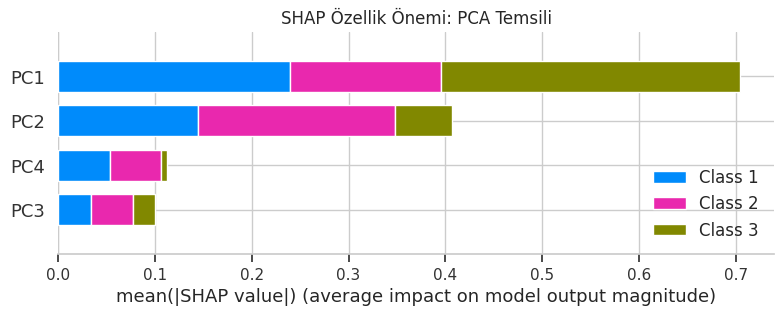

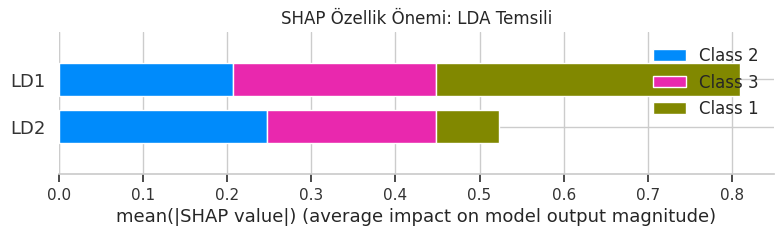

In [ ]:
import shap
import matplotlib.pyplot as plt

def run_shap_analysis(model, X_data, title, feature_prefix):
    # Explainer kurulumu
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_data)

    # Özellik isimlerini oluştur (PC1, PC2... veya LD1, LD2...)
    feature_names = [f'{feature_prefix}{i+1}' for i in range(X_data.shape[1])]
    class_names = ['Class 1', 'Class 2', 'Class 3']

    # Bar plot çizimi
    plt.figure(figsize=(10, 5))
    shap.summary_plot(shap_values, X_data, plot_type="bar",
                      feature_names=feature_names, class_names=class_names, show=False)
    plt.title(f"SHAP Özellik Önemi: {title}")
    plt.show()

# --- 1. PCA Temsili için SHAP ---
# PCA modelimizi (data_rep_2 içindeki X_train) tekrar fit edip analiz edelim
model_pca = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_pca, y_train.squeeze())
run_shap_analysis(model_pca, X_val_pca, "PCA Temsili", "PC")

# --- 2. LDA Temsili için SHAP ---
# LDA modelimizi (data_rep_3 içindeki X_train) tekrar fit edip analiz edelim
model_lda = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train_lda, y_train.squeeze())
run_shap_analysis(model_lda, X_val_lda, "LDA Temsili", "LD")

LDA'nın Verimliliği: LDA grafiğinde LD1, tüm sınıfların ayrılmasında ezici bir üstünlüğe sahip. Model, kararlarının neredeyse tamamını tek bir ana bileşene (LD1) dayandırarak çok daha sade ve odaklanmış bir mantık kurmuş.

PCA'nın Dağılımı: PCA grafiğinde önem değerleri bileşenler arasında (PC1, PC2, PC3) daha fazla yayılmış durumda. Bu da PCA'nın sınıf farklarından ziyade genel varyansa odaklandığını ve modelin karar vermek için daha fazla boyuta ihtiyaç duyduğunu gösteriyor.

Sınıf Bazlı Farklılıklar: Renklere baktığımızda, her iki yöntemde de bileşenlerin farklı sınıflar üzerinde farklı "ağırlıklara" sahip olduğunu görüyoruz. Örneğin, LD1 her üç sınıfın ayrımına da yüksek katkı sağlarken, PCA'da PC1 belirli sınıfları ayırmada daha baskın kalmış.

LDA, model için çok daha "açıklanabilir" ve "kararlı" bir zemin hazırlayarak, karmaşıklığı en aza indirip performansı maksimize etmiştir.

# Teşekkürler...